# Build a Model That Generalizes
## Modul 02 — PeDaS 2026

Pada modul ini kita akan membuat model klasifikasi untuk memprediksi **kategori penyalahgunaan domain** pada data imitasi IDADX.

Model yang digunakan adalah **Support Vector Machine (SVM)**. Agar alurnya mudah diikuti, prosesnya dibagi menjadi beberapa chapter:

1. mengenal data dan target;
2. menyiapkan data;
3. memahami Macro-F1;
4. membuat baseline;
5. membangun pipeline SVM;
6. melakukan cross-validation;
7. melakukan hyperparameter tuning;
8. mengevaluasi model final;
9. membahas langkah lanjutan dan kesalahan yang sering terjadi.

Metrik evaluasi yang digunakan dari awal sampai akhir adalah **Macro-F1**.

## Chapter 1 — Persiapan

Jalankan seluruh import pada satu cell. `RANDOM_STATE` dipakai agar pembagian data dan hasil eksperimen dapat diulang.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 2026

## Chapter 2 — Membaca data

In [2]:
IDADX_NAME = "data/WSdata-idadx.phishes_10000_masked.csv"
idadx_raw = pd.read_csv(IDADX_NAME)
print(f"IDADX: {idadx_raw.shape[0]:,} baris × {idadx_raw.shape[1]} kolom")

IDADX: 10,000 baris × 14 kolom


In [3]:
idadx_raw.head()

,url,brand,discovered,confidence_level,ip,domain,sld,resolved,handle,category,registrar,registration_date,handle_status,resolved_status
0,https://***********************.go.id.test/acc...,PesanKita Simulasi,2026-06-16 19:48:08,100,198.51.100.9,***********************.go.id.test,go.id,1,1,online gambling,Registrar Simulasi 17,2020-05-28,1,1
1,http://*********.desa.id.test/promo/item-08250,NaN,2025-02-16 19:52:58,100,203.0.113.68,*********.desa.id.test,desa.id,1,1,online gambling,Registrar Simulasi 13,2025-06-01,1,1
2,https://*********.go.id.test/access/item-00175,-,2026-06-08 06:35:12,50,192.0.2.19,*********.go.id.test,go.id,1,1,online gambling,Registrar Simulasi 23,2015-09-07,1,1
3,https://******.id.test/service/item-06065,NaN,2025-10-01 08:23:26,100,203.0.113.129,******.id.test,id,1,1,phishing,Registrar Simulasi 10,2017-11-23,1,1
4,https://*********.desa.id.test/member/item-00295,AkunNusa Simulasi,2025-10-05 20:37:28,90,NaN,*********.desa.id.test,desa.id,1,1,online gambling,Registrar Simulasi 13,2015-11-17,1,1


Kolom yang akan diprediksi adalah `category`. Sebelum membuat model, rapikan penulisan label dengan menghapus spasi di awal/akhir dan mengubahnya menjadi huruf kecil.

Duplikat penuh juga dihapus agar baris yang sama persis tidak dihitung dua kali.

In [4]:
idadx = idadx_raw.copy()

idadx["category"] = (
    idadx["category"]
    .str.strip()
    .str.lower()
)

idadx = idadx.drop_duplicates().reset_index(drop=True)

print(f"Jumlah data setelah pembersihan: {len(idadx):,}")
idadx["category"].value_counts()

Jumlah data setelah pembersihan: 9,900


category
online gambling    4944
phishing           3053
other               659
spam                441
malware             353
brand               207
fakeshop            149
violence             73
piiexposure          21
Name: count, dtype: int64

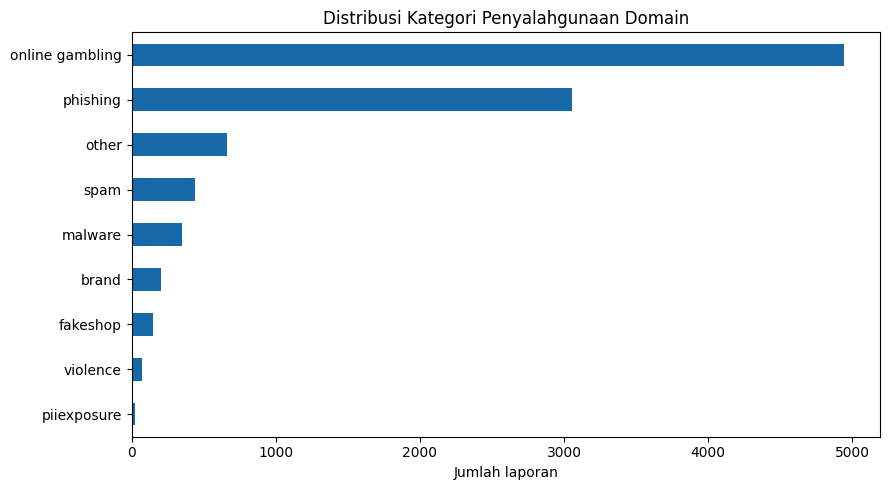

In [5]:
category_count = idadx["category"].value_counts().sort_values()

category_count.plot(
    kind="barh",
    figsize=(9, 5),
    color="#1769aa"
)

plt.title("Distribusi Kategori Penyalahgunaan Domain")
plt.xlabel("Jumlah laporan")
plt.ylabel("")
plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa jumlah data pada setiap kategori tidak seimbang. Kategori yang besar dapat memiliki ribuan baris, sedangkan kategori kecil hanya memiliki puluhan baris.

Kondisi seperti ini menjadi alasan utama kita tidak memakai accuracy sebagai metrik lomba. Model yang hanya bagus pada kategori besar dapat memperoleh accuracy tinggi, walaupun hampir selalu gagal mengenali kategori kecil.

## Chapter 3 — Menentukan fitur dan target

Untuk menjaga contoh tetap sederhana, beberapa kolom teks digabung menjadi satu:

- `url`;
- `brand`;
- `sld`;
- `registrar`.

Kolom status seperti `resolved`, `handle`, dan `resolved_status` tidak digunakan. Dalam penggunaan nyata, status tersebut bisa baru diketahui setelah laporan diproses. Memakainya sebagai fitur dapat menghasilkan **data leakage**.

Bagian nomor item pada URL imitasi dihapus karena nomor tersebut dibuat saat data disimulasikan dan tidak memiliki arti pada data asli.

In [6]:
def clean_url(url):
    url = str(url)
    url = re.sub(r"item-\d+", "", url, flags=re.IGNORECASE)
    return url


idadx["text"] = (
    "url " + idadx["url"].fillna("").map(clean_url)
    + " brand " + idadx["brand"].fillna("")
    + " sld " + idadx["sld"].fillna("")
    + " registrar " + idadx["registrar"].fillna("")
)

X = idadx["text"]
y = idadx["category"]

print("Jumlah kategori:", y.nunique())
print("Contoh fitur:")
print(X.iloc[0])

Jumlah kategori: 9
Contoh fitur:
url https://***********************.go.id.test/account/ brand PesanKita Simulasi sld go.id registrar Registrar Simulasi 17


Data dibagi menjadi:

- **80% development data**, untuk melatih dan memilih model;
- **20% test data**, untuk evaluasi terakhir.

`stratify=y` menjaga agar proporsi kategori pada kedua bagian tetap mendekati data awal. Test data tidak digunakan saat memilih parameter model.

In [7]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Development data : {len(X_dev):,}")
print(f"Test data        : {len(X_test):,}")

Development data : 7,920
Test data        : 1,980


## Chapter 4 — Metrik evaluasi: Macro-F1

### Mengapa Macro-F1?

Macro-F1 menghitung F1 untuk **setiap kategori secara terpisah**, lalu mengambil rata-ratanya. Semua kategori mendapat bobot yang sama, berapa pun jumlah datanya.

Ini sesuai untuk data PANDI yang tidak seimbang. Kesalahan pada kategori kecil tetap memengaruhi skor akhir secara nyata.

Untuk kategori ke-$k$:

$$
\text{Precision}_k = \frac{TP_k}{TP_k + FP_k}
$$

$$
\text{Recall}_k = \frac{TP_k}{TP_k + FN_k}
$$

$$
F1_k = 2\times\frac{\text{Precision}_k\times\text{Recall}_k}
{\text{Precision}_k+\text{Recall}_k}
$$

Jika terdapat $K$ kategori, Macro-F1 dihitung dengan:

$$
\text{Macro-F1}=\frac{F1_1+F1_2+\cdots+F1_K}{K}
$$

Nilai terbaik adalah 1 dan nilai terburuk adalah 0.

### Contoh sederhana

Pada contoh kecil di cell berikut, F1 untuk kategori A, B, dan C dihitung satu per satu. Hasilnya kemudian dirata-ratakan. Dengan cara ini, kategori A tidak dapat menutupi kegagalan model pada kategori B atau C hanya karena jumlah datanya lebih besar.

In [8]:
# Contoh kecil perhitungan Macro-F1
y_true_example = ["A", "A", "B", "B", "C", "C"]
y_pred_example = ["A", "A", "A", "B", "B", "C"]

class_names = ["A", "B", "C"]
f1_per_class = f1_score(
    y_true_example,
    y_pred_example,
    labels=class_names,
    average=None
)

for class_name, score in zip(class_names, f1_per_class):
    print(f"F1 kategori {class_name}: {score:.4f}")

example_score = f1_per_class.mean()
print(f"Macro-F1       : {example_score:.4f}")

F1 kategori A: 0.8000
F1 kategori B: 0.5000
F1 kategori C: 0.6667
Macro-F1       : 0.6556


Pada scikit-learn, bagian terpenting adalah `average="macro"`. Pilihan ini memerintahkan Python untuk menghitung F1 setiap kategori dan merata-ratakannya tanpa bobot berdasarkan jumlah data.

Kode penilaian yang dapat digunakan pada scoreboard pada prinsipnya cukup pendek:

In [9]:
def competition_score(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

`zero_division=0` digunakan agar kategori yang tidak pernah diprediksi mendapat nilai 0 dan proses penilaian tetap berjalan.

## Chapter 5 — Baseline

Baseline adalah model pembanding paling sederhana. Di sini baseline selalu memilih kategori yang paling sering muncul pada development data.

Model berikut tentu bukan solusi lomba. Fungsinya hanya untuk menjawab pertanyaan: *apakah model SVM benar-benar lebih baik daripada tebakan yang sangat sederhana?*

In [10]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_dev.to_frame(), y_dev)

baseline_pred = baseline.predict(X_test.to_frame())
baseline_score = competition_score(y_test, baseline_pred)

print(f"Macro-F1 baseline: {baseline_score:.4f}")

Macro-F1 baseline: 0.0740


## Chapter 6 — Pipeline TF-IDF dan SVM

SVM tidak dapat membaca URL atau teks secara langsung. Teks harus diubah menjadi angka terlebih dahulu.

Pipeline berikut melakukan dua pekerjaan secara berurutan:

1. `TfidfVectorizer` mengubah potongan karakter menjadi fitur numerik;
2. `LinearSVC` mempelajari batas pemisah antarkategori.

Karakter n-gram cocok digunakan untuk URL karena dapat menangkap pola pendek seperti nama folder, tanda hubung, ekstensi, atau potongan nama domain.

Keuntungan pipeline adalah proses TF-IDF dan SVM selalu dijalankan sebagai satu kesatuan. Saat cross-validation dilakukan, TF-IDF hanya belajar dari training fold sehingga mengurangi risiko leakage.

In [11]:
svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            max_features=10_000
        )
    ),
    (
        "svm",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

`LinearSVC` dipilih karena TF-IDF menghasilkan matriks yang besar tetapi jarang terisi. Linear SVM biasanya jauh lebih ringan untuk kondisi ini dibandingkan SVM dengan kernel RBF.

`class_weight="balanced"` memberi perhatian lebih besar pada kategori yang jumlahnya sedikit. Pilihan ini tetap harus dinilai melalui cross-validation; tidak selalu menghasilkan model terbaik.

## Chapter 7 — Cross-validation

Satu kali pembagian train-validation dapat memberikan hasil yang kebetulan terlalu tinggi atau terlalu rendah. Cross-validation mengulang proses pelatihan pada beberapa bagian data.

Kita menggunakan **3-fold Stratified Cross-Validation**:

- data development dibagi menjadi tiga fold;
- model dilatih pada dua fold dan dinilai pada satu fold;
- proses diulang sampai setiap fold pernah menjadi validation data;
- seluruh fold memakai Macro-F1.

In [12]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    svm_pipeline,
    X_dev,
    y_dev,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1
)

print("Macro-F1 setiap fold:", np.round(cv_scores, 4))
print(f"Rata-rata Macro-F1 : {cv_scores.mean():.4f}")
print(f"Standar deviasi    : {cv_scores.std():.4f}")

Macro-F1 setiap fold: [0.1199 0.1188 0.1193]
Rata-rata Macro-F1 : 0.1193
Standar deviasi    : 0.0005


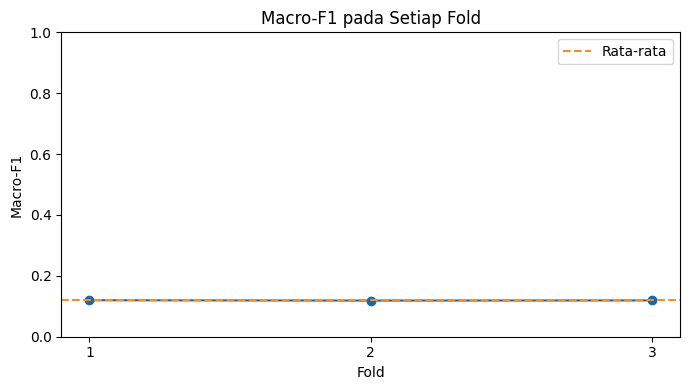

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker="o", color="#1769aa")
plt.axhline(cv_scores.mean(), linestyle="--", color="#f28e2b", label="Rata-rata")
plt.xticks(range(1, len(cv_scores) + 1))
plt.ylim(0, 1)
plt.xlabel("Fold")
plt.ylabel("Macro-F1")
plt.title("Macro-F1 pada Setiap Fold")
plt.legend()
plt.tight_layout()
plt.show()

Nilai rata-rata menunjukkan performa umum pada development data. Standar deviasi menunjukkan seberapa berubah skor antar-fold. Standar deviasi kecil berarti hasil antar-fold lebih konsisten, tetapi bukan jaminan bahwa model akan selalu bagus pada data baru.

## Chapter 8 — Hyperparameter tuning

Hyperparameter adalah pengaturan yang ditentukan sebelum model dilatih. Kita akan mencoba beberapa nilai:

- `C`: mengatur kekuatan regularisasi SVM;
- `class_weight`: membandingkan bobot biasa dan bobot seimbang.

Nilai `C` kecil memberi regularisasi lebih kuat. Nilai `C` besar membuat model lebih berusaha menyesuaikan training data dan dapat meningkatkan risiko overfitting.

Grid search mencoba seluruh kombinasi berikut. Enam kombinasi dinilai menggunakan cross-validation dan Macro-F1 yang sama. Rentang n-gram dibuat tetap agar contoh tuning tidak terlalu panjang.

In [14]:
parameter_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__class_weight": [None, "balanced"]
}

search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1
)

search.fit(X_dev, y_dev)

print("Parameter terbaik:")
print(search.best_params_)
print(f"Macro-F1 CV terbaik: {search.best_score_:.4f}")

Parameter terbaik:
{'svm__C': 10, 'svm__class_weight': 'balanced'}
Macro-F1 CV terbaik: 0.1205


In [15]:
tuning_result = pd.DataFrame(search.cv_results_)

tuning_result[
    [
        "param_svm__C",
        "param_svm__class_weight",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values("mean_test_score", ascending=False).head(10)

,param_svm__C,param_svm__class_weight,mean_test_score,std_test_score
5,10.0,balanced,0.120513,0.000549
4,10.0,None,0.120166,0.001027
2,1.0,None,0.119806,0.001181
1,0.1,balanced,0.119424,0.003839
3,1.0,balanced,0.119321,0.000468
0,0.1,None,0.119120,0.000667


`best_score_` adalah hasil terbaik pada cross-validation development data. Nilai tersebut belum menjadi hasil final karena parameter dipilih berdasarkan data yang sama.

Test data baru dibuka setelah kombinasi parameter terbaik ditetapkan.

## Chapter 9 — Evaluasi model final

`GridSearchCV` secara otomatis melatih ulang kombinasi terbaik menggunakan seluruh development data. Model tersebut tersedia pada `best_estimator_`.

In [16]:
best_model = search.best_estimator_
test_prediction = best_model.predict(X_test)

test_score = competition_score(y_test, test_prediction)

print(f"Macro-F1 baseline : {baseline_score:.4f}")
print(f"Macro-F1 SVM      : {test_score:.4f}")

Macro-F1 baseline : 0.0740
Macro-F1 SVM      : 0.1135


Macro-F1 di atas adalah hasil utama eksperimen. Bandingkan dengan baseline dan nilai cross-validation.

Jika skor test jauh lebih rendah daripada cross-validation, kemungkinan model terlalu menyesuaikan development data atau distribusi test berbeda. Jangan mengulang tuning menggunakan test data karena test data akan kehilangan fungsinya sebagai evaluasi akhir.

Laporan berikut digunakan untuk melihat F1 setiap kategori. Angka utama lomba tetap Macro-F1.

In [17]:
report = classification_report(
    y_test,
    test_prediction,
    output_dict=True,
    zero_division=0
)

report_table = pd.DataFrame(report).T
report_table.loc[list(search.classes_), ["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
brand,0.018868,0.024390,0.021277,41.0
fakeshop,0.000000,0.000000,0.000000,30.0
malware,0.000000,0.000000,0.000000,71.0
online gambling,0.587719,0.474216,0.524902,989.0
other,0.000000,0.000000,0.000000,132.0
phishing,0.441011,0.514754,0.475038,610.0
piiexposure,0.000000,0.000000,0.000000,4.0
spam,0.000000,0.000000,0.000000,88.0
violence,0.000000,0.000000,0.000000,15.0


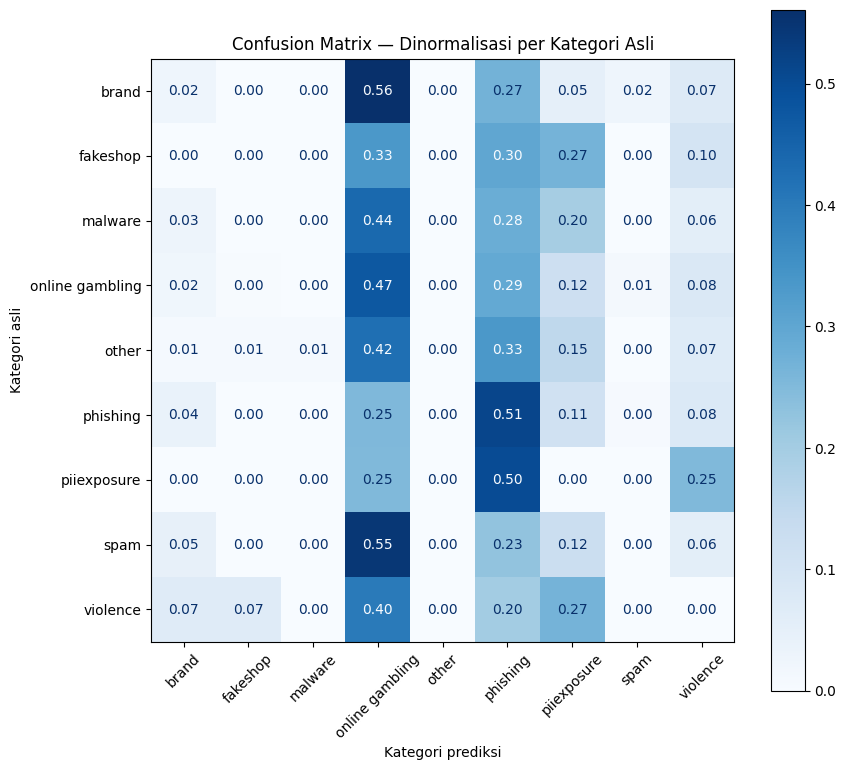

In [18]:
fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    labels=search.classes_,
    display_labels=search.classes_,
    normalize="true",
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f",
    ax=ax
)

ax.set_title("Confusion Matrix — Dinormalisasi per Kategori Asli")
ax.set_xlabel("Kategori prediksi")
ax.set_ylabel("Kategori asli")
plt.tight_layout()
plt.show()

Confusion matrix membantu melihat pasangan kategori yang sering tertukar. Setiap baris dinormalisasi sehingga kategori kecil tetap terlihat. Grafik ini dipakai untuk diagnosis model, sedangkan ranking scoreboard tetap menggunakan satu angka: Macro-F1.

## Chapter 10 — Hal yang perlu diingat

### Kelebihan pendekatan ini

- kode relatif singkat dan dapat dijalankan pada komputer biasa;
- Linear SVM cocok untuk fitur TF-IDF yang besar dan sparse;
- pipeline menjaga preprocessing tetap konsisten;
- cross-validation memberi gambaran yang lebih stabil daripada satu validation split;
- Macro-F1 memberi perhatian yang sama kepada setiap kategori.

### Keterbatasan

- SVM linear hanya mempelajari pola yang dapat dipisahkan secara linear pada ruang TF-IDF;
- output `LinearSVC` bukan probabilitas;
- kategori dengan data sangat sedikit tetap sulit dipelajari;
- URL pada data imitasi sudah dimasking, sehingga sebagian informasi penting hilang;
- skor pada data imitasi tidak dapat dianggap sebagai skor pada data asli PANDI.

### Pitfall yang sering terjadi

1. Memilih model berdasarkan test data.
2. Melakukan TF-IDF pada seluruh data sebelum cross-validation.
3. Memasukkan target atau status hasil penanganan sebagai fitur.
4. Mengubah label kategori kecil hanya agar skor meningkat.
5. Mencoba terlalu banyak parameter, lalu hanya melaporkan hasil terbaik.

## Chapter 11 — Eksperimen lanjutan

Setelah baseline SVM ini dipahami, eksperimen dapat dilanjutkan secara bertahap:

1. membandingkan fitur URL saja dengan URL + metadata;
2. memakai temporal split untuk menguji laporan pada periode yang lebih baru;
3. menambah data terverifikasi pada kategori yang sangat kecil;
4. mencoba representasi pretrained dan tetap memakai Macro-F1 serta split yang sama.

### Contoh opsional: pretrained sentence embedding + SVM

Contoh berikut mengubah teks menjadi embedding dengan model pretrained, kemudian melatih Linear SVM. 

Model pretrained ini dibuat untuk teks umum, bukan khusus URL. Karena itu, hasilnya harus dibandingkan dengan TF-IDF; model yang lebih kompleks belum tentu lebih baik.

In [20]:
RUN_PRETRAINED_EXAMPLE = True

if RUN_PRETRAINED_EXAMPLE:
    # Jalankan sekali jika paket belum tersedia:
    # %pip install sentence-transformers
    from sentence_transformers import SentenceTransformer

    encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

    X_dev_embedding = encoder.encode(X_dev.tolist(), show_progress_bar=True)
    X_test_embedding = encoder.encode(X_test.tolist(), show_progress_bar=True)

    pretrained_svm = LinearSVC(
        C=1,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    pretrained_svm.fit(X_dev_embedding, y_dev)
    pretrained_prediction = pretrained_svm.predict(X_test_embedding)

    pretrained_score = competition_score(y_test, pretrained_prediction)
    print(f"Macro-F1 pretrained + SVM: {pretrained_score:.4f}")
else:
    print("Contoh pretrained tidak dijalankan.")

C:\Anaconda\envs\GitHub\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 62/62 [00:11<00:00,  5.21it/s]


Macro-F1 pretrained + SVM: 0.1211


## Penutup

Model yang generalize dibangun melalui disiplin proses:

1. tentukan target dan metrik;
2. pisahkan test data sejak awal;
3. masukkan preprocessing ke dalam pipeline;
4. lakukan cross-validation;
5. tuning dengan metrik yang sama;
6. buka test data satu kali untuk evaluasi final;
7. periksa kesalahan per kategori sebelum menarik kesimpulan.

Untuk babak penyisihan PeDaS 2026, metrik ranking adalah:

> **Macro-F1, dihitung pada seluruh kategori target dan tanpa pembulatan sebelum penentuan ranking.**

Jika dua peserta memperoleh nilai Macro-F1 yang benar-benar sama, waktu submission valid digunakan sebagai tie-breaker sesuai aturan lomba yang ditetapkan panitia.